Exploratory Data Analysis (EDA)

In this phase, we analyze the cleaned dataset to identify patterns, trends and relationships between features and customer churn.

In [3]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
df=pd.read_csv("ecommerce_customer_churn_dataset.csv")
df.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


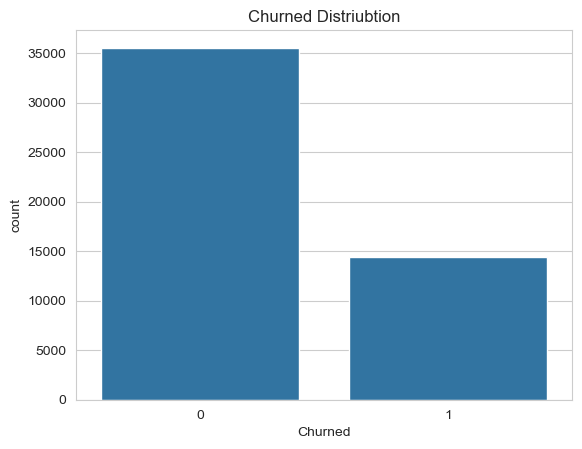

In [14]:
#Churn Distribution
sns.countplot(x="Churned",data=df)    #High churn = bad business                                     
plt.title("Churned Distriubtion")     #Low churn = good retention
plt.show()

In [ ]:
Insight:

- Majority of customers are not churned.
- However, a significant number of customers have churned, which needs attention.

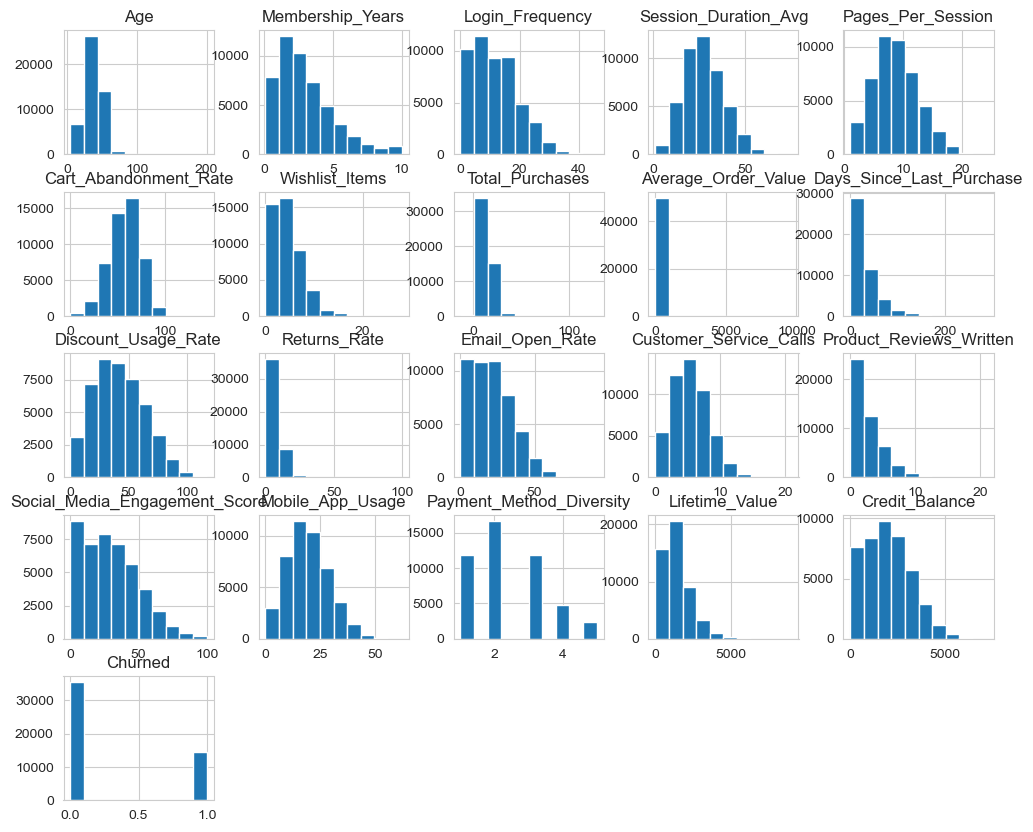

In [18]:
#Numerical Feature Analysis
#Check distribution
#Identify skewness
num_cols = df.select_dtypes(include=["int64","float64"]).columns

df[num_cols].hist(figsize=(12,10))
plt.show()

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  object 
 2   Country                        50000 non-null  object 
 3   City                           50000 non-null  object 
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase       47000 non-null 

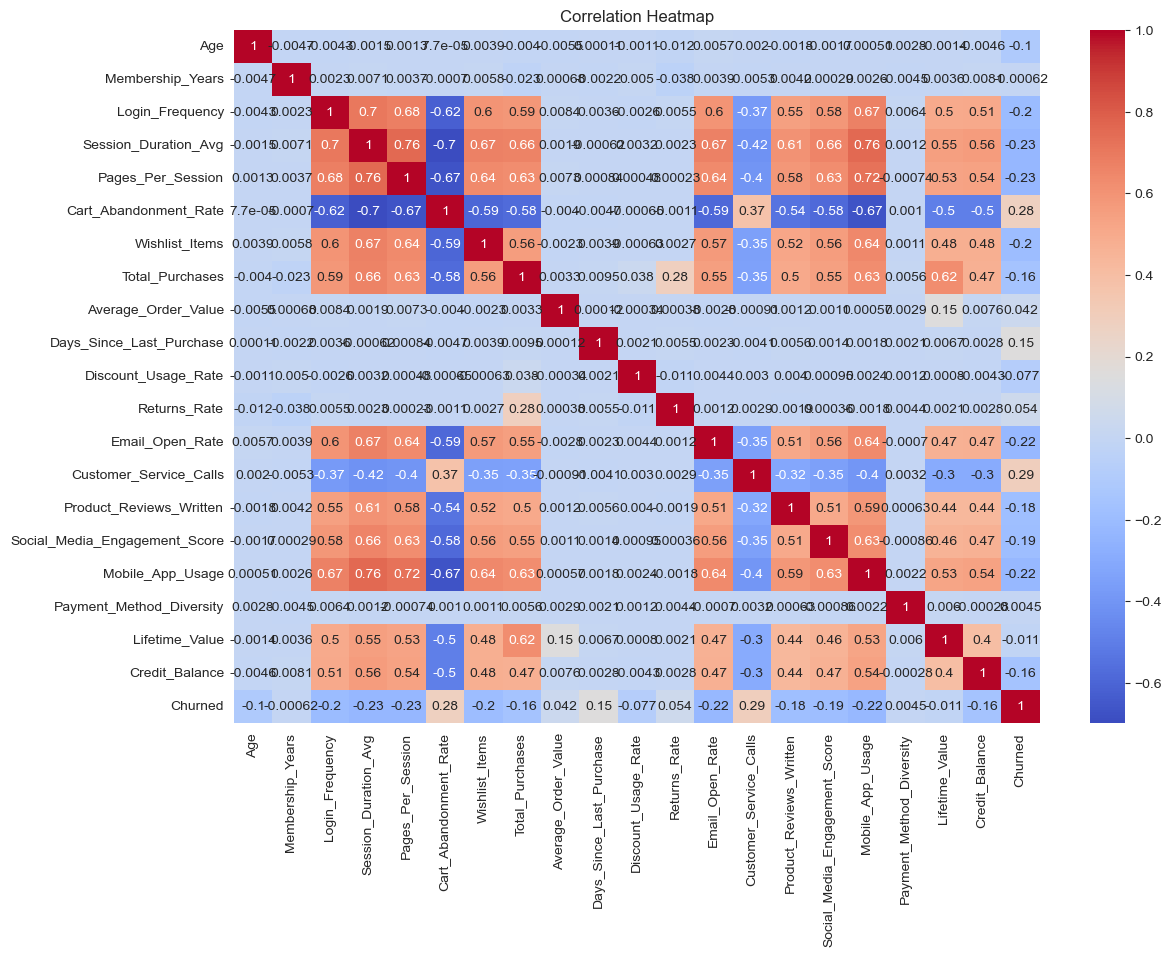

In [43]:
#Correlation Heatmap
#which feature ie related to churn
plt.figure(figsize=(13,9))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
 Insight:

- Features like login frequency, total purchases, and engagement show strong relation with churn.
- These features are important for prediction.

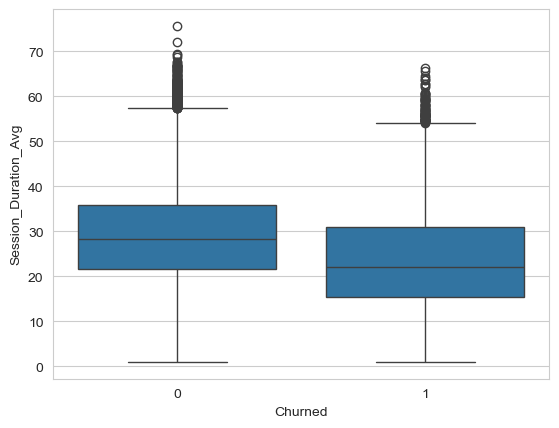

In [28]:
#Feature vs Churn Analysis
sns.boxplot(x="Churned", y="Session_Duration_Avg",data=df)
plt.show()

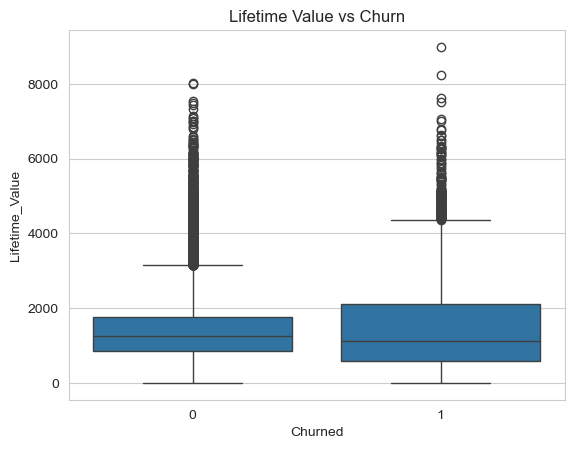

In [40]:
#High charges → churn increase
sns.boxplot(x="Churned", y="Lifetime_Value", data=df)
plt.title("Lifetime Value vs Churn")
plt.show()
# Insight:
# Customers with low session duration are more likely to churn

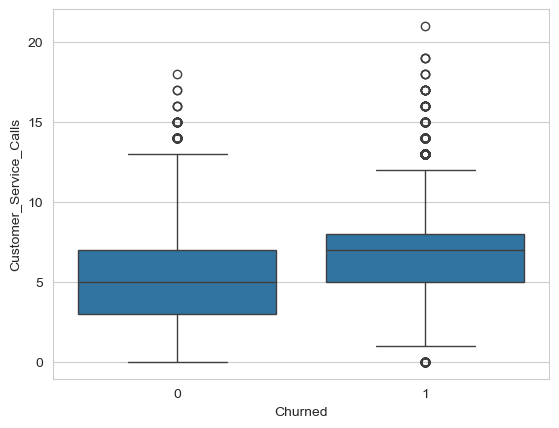

In [38]:
sns.boxplot(x="Churned", y="Customer_Service_Calls", data=df)
plt.show()
#More complaints → churn

In [39]:
df.groupby("Churned")["Lifetime_Value"].mean()
# churned customers spend more or less

Churned
0    1446.805875
1    1425.423236
Name: Lifetime_Value, dtype: float64

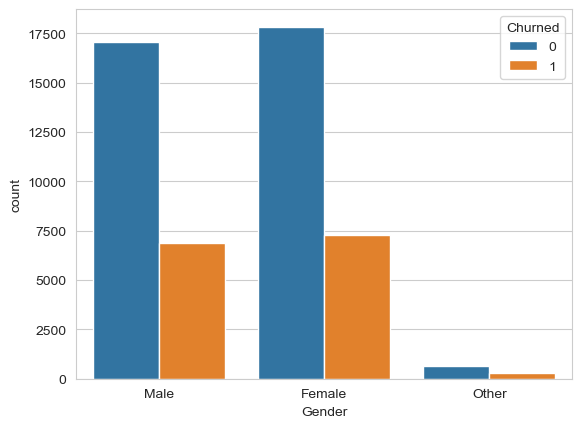

In [27]:
#Categorical Analysis
sns.countplot(x="Gender",hue="Churned",data=df)
plt.show()

In [ ]:
Overall EDA Insights:

- Low engagement customers are more likely to churn.
- Customers with fewer purchases and low activity show high churn risk.
- Customer behavior plays a major role in churn prediction.